<a href="https://colab.research.google.com/github/RaffyNadjib/UTS-PCD/blob/main/UTS_PCD_Soal2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rata-rata piksel Original : 41.75
Rata-rata piksel LPF      : 41.75
Rata-rata piksel HPF      : 27.33
Rata-rata piksel BPF      : 47.81


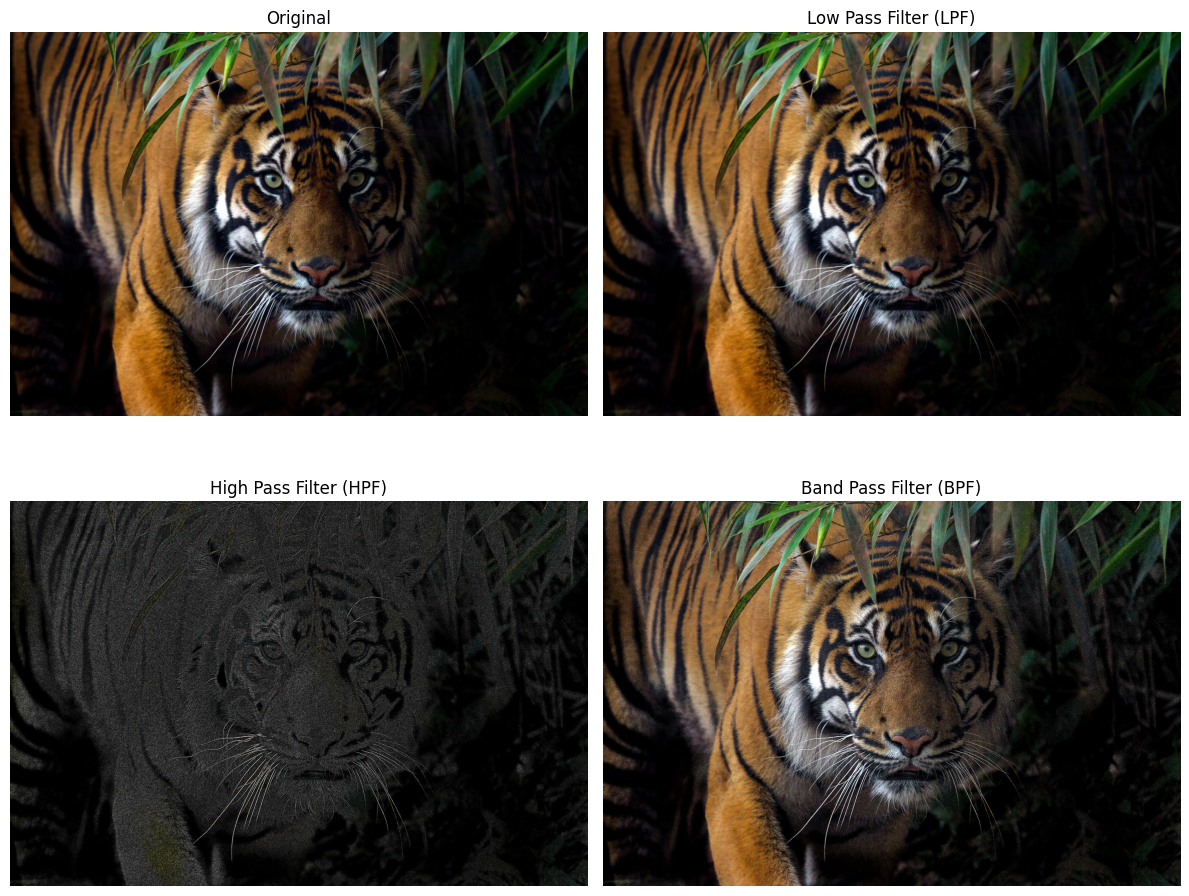

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Nama: ACHMAD RAFFY NADJIB
# NIM: 23424047
# Program Studi: Informatika

# 1. Baca citra berwarna
# Ganti 'nama_gambar.jpg' dengan nama file gambar yang kamu upload di Colab
img_bgr = cv2.imread('Tiger.jpg')

if img_bgr is not None:
    # Konversi warna dari BGR (bawaan OpenCV) ke RGB (bawaan Matplotlib)
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 2. Definisi 3 Kernel
    # Low Pass Filter (LPF)
    kernel_lpf = np.ones((3, 3), np.float32) / 9

    # High Pass Filter (HPF)
    kernel_hpf = np.array([[-1, -1, -1],
                           [-1,  8, -1],
                           [-1, -1, -1]], dtype=np.float32)

    # Band Pass Filter (BPF) / Sharpening
    kernel_bpf = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float32)

    # 3. Terapkan ketiga kernel pada gambar yang sama
    img_lpf = cv2.filter2D(img, -1, kernel_lpf)
    img_hpf = cv2.filter2D(img, -1, kernel_hpf)
    img_bpf = cv2.filter2D(img, -1, kernel_bpf)

    # Hitung dan cetak nilai piksel rata-rata untuk analisa
    print(f"Rata-rata piksel Original : {np.mean(img):.2f}")
    print(f"Rata-rata piksel LPF      : {np.mean(img_lpf):.2f}")
    print(f"Rata-rata piksel HPF      : {np.mean(img_hpf):.2f}")
    print(f"Rata-rata piksel BPF      : {np.mean(img_bpf):.2f}")

    # 4. Tampilkan hasil dalam satu figure berisi empat gambar
    titles = ['Original', 'Low Pass Filter (LPF)', 'High Pass Filter (HPF)', 'Band Pass Filter (BPF)']
    images = [img, img_lpf, img_hpf, img_bpf]

    plt.figure(figsize=(12, 10))
    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Gambar tidak ditemukan. Pastikan file sudah di-upload ke Google Colab.")